In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mnist-dataset/train-images.idx3-ubyte
/kaggle/input/mnist-dataset/t10k-labels.idx1-ubyte
/kaggle/input/mnist-dataset/t10k-images.idx3-ubyte
/kaggle/input/mnist-dataset/train-labels.idx1-ubyte
/kaggle/input/mnist-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte
/kaggle/input/mnist-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte
/kaggle/input/mnist-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte
/kaggle/input/mnist-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hojjatk/mnist-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/mnist-dataset


In [90]:
def load_dataset(file_path,image,label):
    if image:
        with open(file_path,'rb') as file:
            file.read(16)
            binary_data=file.read()
        numpy_data=np.frombuffer(binary_data,dtype=np.uint8)
        data=numpy_data.size//784
        numpy_data=numpy_data.reshape(data,784)
        return numpy_data
    if label:
        with open(file_path,'rb') as file:
            file.read(8)
            binary_data=file.read()
        label_data=np.frombuffer(binary_data,dtype=np.uint8)
        return label_data
            
X_train=load_dataset('/kaggle/input/mnist-dataset/train-images.idx3-ubyte',image=True,label=False)
Y_test=load_dataset('/kaggle/input/mnist-dataset/t10k-labels.idx1-ubyte',image=False,label=True)
X_test=load_dataset('/kaggle/input/mnist-dataset/t10k-images.idx3-ubyte',image=True,label=False)
Y_train=load_dataset('/kaggle/input/mnist-dataset/train-labels.idx1-ubyte',image=False,label=True)   


In [91]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
X_train=X_train.reshape(X_train.shape[0],28,28)
X_test=X_test.reshape(X_test.shape[0],28,28)
l=X_train/255
y_train=to_categorical(Y_train,10)
y_test=to_categorical(Y_test,10)
y_train.shape
y_test.shape



(10000, 10)

In [54]:
X_test.shape

(10000, 28, 28)

In [56]:
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv2D,Flatten,MaxPooling2D,Dense,Dropout

In [93]:
model=Sequential([
    Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.1),
    Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.1),
    Conv2D(filters=32,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.1),
    Flatten(),
    Dense(units=120,activation='relu'),
    Dropout(0.1),
    Dense(units=60,activation='relu'),
    Dropout(0.1),
    Dense(units=60,activation='relu'),
    Dropout(0.1),
    Dense(units=10,activation='softmax')
    
])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)                   │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 3, 3, 32)            │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 1, 1, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 1, 1, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 120)                 │           3,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 60)                  │           7,260 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 60)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 60)                  │           3,660 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 60)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 10)                  │             610 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,770 (206.13 KB)

 Trainable params: 52,770 (206.13 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
model.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [100]:
train=model.fit(X_train,y_train,epochs=10,validation_split=0.1,batch_size=32)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9781 - loss: 0.0830 - val_accuracy: 0.9860 - val_loss: 0.0642
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9801 - loss: 0.0781 - val_accuracy: 0.9852 - val_loss: 0.0622
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9792 - loss: 0.0789 - val_accuracy: 0.9855 - val_loss: 0.0550
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9805 - loss: 0.0740 - val_accuracy: 0.9848 - val_loss: 0.0627
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9788 - loss: 0.0762 - val_accuracy: 0.9855 - val_loss: 0.0593
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.9817 - loss: 0.0704 - val_accuracy: 0.9878 - val_loss: 0.0476
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.9811 - loss: 0.0708 - val_accuracy: 0.9878 - val_loss: 0.0537
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9828 -

In [103]:
import pandas as pd
pd.DataFrame(train.history)

,accuracy,loss,val_accuracy,val_loss
0,0.977926,0.084379,0.986000,0.064181
1,0.979352,0.079532,0.985167,0.062232
2,0.978648,0.081133,0.985500,0.055049
3,0.979926,0.076539,0.984833,0.062709
4,0.979611,0.076090,0.985500,0.059334
5,0.980815,0.072338,0.987833,0.047596
6,0.981093,0.070578,0.987833,0.053697
7,0.982167,0.067643,0.987167,0.055775
8,0.981963,0.069664,0.988667,0.050625
9,0.982741,0.065014,0.988000,0.048473


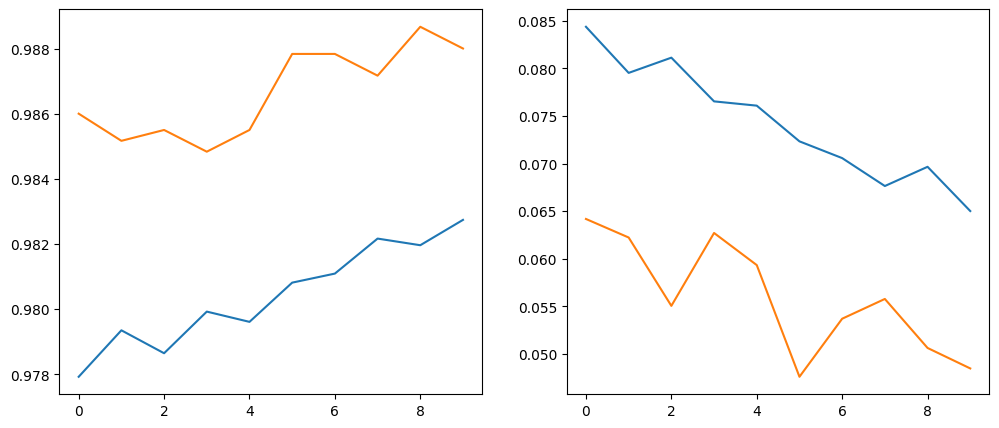

In [111]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train.history['accuracy'])
plt.plot(train.history['val_accuracy'])
plt.subplot(1,2,2)
plt.plot(train.history['loss'])
plt.plot(train.history['val_loss'])

In [112]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9843 - loss: 0.0715


[0.06133565679192543, 0.9861000180244446]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
[[7.9557346e-18 1.0000000e+00 1.6212938e-12 3.8734033e-15 4.2706886e-14
  4.8293876e-09 8.5223625e-13 1.5020451e-12 2.0393777e-11 1.8537874e-20]]
Label: 1


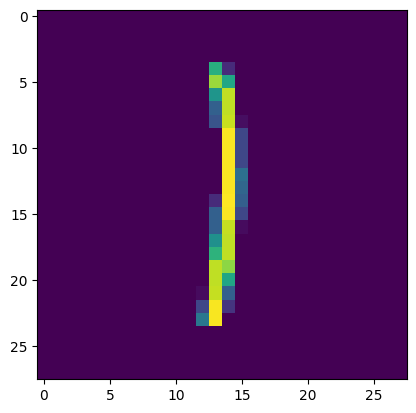

In [122]:
prediction = model.predict(np.expand_dims(X_test[40], axis=0))
plt.imshow(X_test[40])

print(prediction)  # Output probabilities for each class
print("Label:",np.argmax(prediction))